# Machine Learning Wrapup - Regression

## Libraries

In [3]:
# DATA MANIPULATION
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import datetime

# STATS
from statsmodels.graphics.gofplots import qqplot

# DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# ML
## PREPROC
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
# METRICS
from sklearn.metrics import r2_score, mean_squared_error
## MODEL
#### BASIC MODELS
###### LINEAR MODELS
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
###### ADVANCED MODELS
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

## Airbnb Prices (Regression)

### Dataset

#### Loading

In [4]:
airbnb_asheville = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/asheville_airbnb.csv"

In [7]:
df = pd.read_csv(airbnb_asheville, index_col = 0)
df

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,$120.00,30,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,$100.00,1,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,$66.00,1,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
3,28806,35.57864,-82.59578,Shared room in hostel,Shared room,1,2.5 shared baths,1.0,6.0,$33.00,1,306,4.71,199,t,156926,https://www.airbnb.com/rooms/156926,20220611041116,2022-06-11,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...
4,28806,35.57808,-82.63689,Private room in home,Private room,2,1 private bath,1.0,1.0,$45.00,2,51,4.98,78,f,197263,https://www.airbnb.com/rooms/197263,20220611041116,2022-06-11,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,28806,35.61922,-82.65641,Camper/RV,Entire home/apt,2,1 bath,NaN,1.0,$30.00,1,39,4.54,354,t,51838711,https://www.airbnb.com/rooms/51838711,20220611041116,2022-06-11,Rustic Camper minutes to Asheville,"Rustic, cozy, camper with lots of wood detaili..."
2852,28732,35.42588,-82.57732,Entire guesthouse,Entire home/apt,2,1 bath,NaN,1.0,$95.00,2,104,4.79,168,t,20910203,https://www.airbnb.com/rooms/20910203,20220611041116,2022-06-11,Mountain Cottage Retreat,Cozy guest cottage in prime location for visit...
2853,28806,35.61355,-82.66020,Entire guest suite,Entire home/apt,4,1 bath,1.0,2.0,$91.00,2,29,5.00,169,t,40617579,https://www.airbnb.com/rooms/40617579,20220611041116,2022-06-11,Relaxing country home right outside of Asheville.,A quiet country home just 15 minutes away from...
2854,28806,35.61215,-82.66623,Entire cabin,Entire home/apt,6,2 baths,3.0,3.0,$299.00,3,35,4.94,237,t,47531339,https://www.airbnb.com/rooms/47531339,20220611041116,2022-06-11,Barefoot Lodge at Dix Creek,Private cabin in rolling landscape that's 15 m...


#### Basic info

In [8]:
df.shape

(2856, 21)

#### Pre-cleaning

##### Duplicated

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2851    False
2852    False
2853    False
2854    False
2855    False
Length: 2856, dtype: bool

In [10]:
nb_duplicated_rows = df.duplicated().sum()
nb_duplicated_rows

0

In [12]:
df.drop_duplicates(inplace=True)

##### Price as a float

*For one price...*

In [15]:
df["price"][0]

'$120.00'

In [16]:
type(df["price"][0])

str

In [17]:
df["price"][0]*10

'$120.00$120.00$120.00$120.00$120.00$120.00$120.00$120.00$120.00$120.00'

In [21]:
float(df["price"][0].replace("$",""))

120.0

In [22]:
float(df["price"][0].replace("$",""))*15

1800.0

*For the entire "price" column...*

In [27]:
df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)

/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_24275/293166301.py:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)


##### Affordable accommodations

<Axes: xlabel='price', ylabel='Count'>

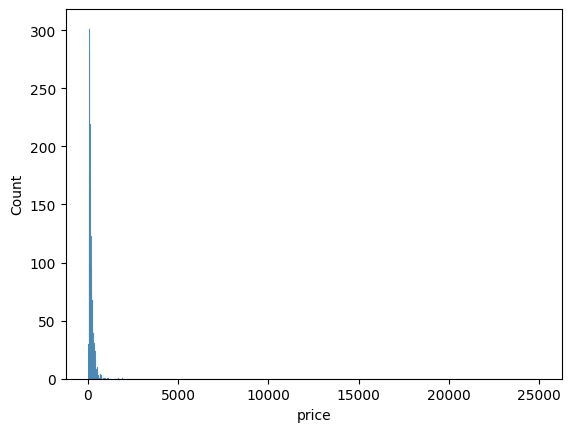

In [29]:
sns.histplot(data = df, x="price")

In [32]:
round(df["price"].describe())

count     2856.0
mean       196.0
std        491.0
min         19.0
25%         98.0
50%        140.0
75%        225.0
max      24999.0
Name: price, dtype: float64

Focus on affordable accomodations for your predictions.

In [33]:
lower_budget = 50
upper_budget = 800

In [36]:
davys_filter = (df["price"] >= lower_budget) & (df["price"] <= upper_budget)
davys_filter

0        True
1        True
2        True
3       False
4       False
        ...  
2851    False
2852     True
2853     True
2854     True
2855     True
Name: price, Length: 2856, dtype: bool

In [39]:
df = df[davys_filter]

<Axes: xlabel='price', ylabel='Count'>

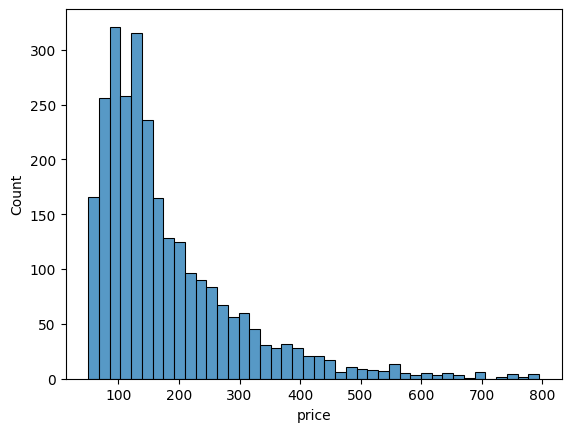

In [40]:
sns.histplot(data = df, x="price")

##### Missing values - First glimpse

In [45]:
# percentage of missing values
# df.isna().sum().sort_values(ascending=False)/len(df)

round(df.isna().mean().sort_values(ascending=False),2)

review_scores_rating      0.06
bedrooms                  0.05
beds                      0.01
description               0.00
name                      0.00
last_scraped              0.00
scrape_id                 0.00
listing_url               0.00
id                        0.00
instant_bookable          0.00
availability_365          0.00
neighbourhood_cleansed    0.00
number_of_reviews         0.00
latitude                  0.00
price                     0.00
bathrooms_text            0.00
accommodates              0.00
room_type                 0.00
property_type             0.00
longitude                 0.00
minimum_nights            0.00
dtype: float64

In [50]:
df["bathrooms_text"].unique()

array(['1 bath', '2.5 shared baths', '1 shared bath', '1.5 baths',
       '1 private bath', '2.5 baths', '2 baths', '2 shared baths',
       '3 baths', '1.5 shared baths', '3.5 baths', '0 shared baths',
       '4.5 baths', '0 baths', '4 baths', 'Half-bath', '7 baths',
       '5 baths', '5.5 baths', '6 baths'], dtype=object)

In [56]:
trysomething = '2.5 shared baths'

In [58]:
float(trysomething.split()[0])

2.5

In [59]:
def bathroom_number_extractor(silly_text):
    if silly_text == "Half-bath":
        return 0.5
    else:
        return float(silly_text.split()[0])

In [62]:
df["nb_bathrooms"] = df["bathrooms_text"].apply(bathroom_number_extractor)
df.drop(columns=["bathrooms_text"], inplace = True)

/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_24275/2669365527.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nb_bathrooms"] = df["bathrooms_text"].apply(bathroom_number_extractor)
/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_24275/2669365527.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["bathrooms_text"], inplace = True)


In [66]:
df["instant_bookable"] = df["instant_bookable"].map({"f":False, 
                                                     "t":True})

/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_24275/1216166316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["instant_bookable"] = df["instant_bookable"].map({"f":False,


#### Selecting features manually

In [48]:
df["room_type"].value_counts()

Entire home/apt    2391
Private room        336
Hotel room           15
Shared room           1
Name: room_type, dtype: int64

In [63]:
df.head(3)

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description,nb_bathrooms
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1.0,1.0,120.0,30,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...,1.0
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1.0,1.0,100.0,1,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...,1.0
2,28806,35.57864,-82.59578,Private room in home,Private room,2,1.0,1.0,66.0,1,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...,2.5


In [68]:
df.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'availability_365', 'instant_bookable', 'id', 'listing_url',
       'scrape_id', 'last_scraped', 'name', 'description', 'nb_bathrooms'],
      dtype='object')

In [70]:
selected_columns = [
    "room_type",
    "accommodates",
    "nb_bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "availability_365",
    "instant_bookable",
    "price"
]

df = df[selected_columns]

#### Pre-cleaning in one single function

In [73]:
def df_pre_cleaning(df):
    # Convert price from string to float
    df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)
    # Affordable
    lower_budget = 50
    upper_budget = 800
    davys_filter = (df["price"] >= lower_budget) & (df["price"] <= upper_budget)
    df = df[davys_filter]
    # Number of Bathrooms
    df["nb_bathrooms"] = df["bathrooms_text"].apply(bathroom_number_extractor)
    # Instant bookable
    df["instant_bookable"] = df["instant_bookable"].map({"f":False, 
                                                     "t":True})    
    # Selecting columns of interest
    selected_columns = [
        "room_type",
        "accommodates",
        "nb_bathrooms",
        "bedrooms",
        "beds",
        "minimum_nights",
        "number_of_reviews",
        "review_scores_rating",
        "availability_365",
        "instant_bookable",
        "price"
    ]

    df = df[selected_columns]
    return df

In [75]:
# df_onemoretime = pd.read_csv(airbnb_asheville, index_col = 0)
# df_onemoretime_precleaned = df_pre_cleaning(df_onemoretime)
# df_onemoretime_precleaned

### Preprocessing

In [77]:
y = df["price"]
X = df.drop(columns=["price"])

In [78]:
X.dtypes

room_type                object
accommodates              int64
nb_bathrooms            float64
bedrooms                float64
beds                    float64
minimum_nights            int64
number_of_reviews         int64
review_scores_rating    float64
availability_365          int64
instant_bookable           bool
dtype: object

In [83]:
# X_num = X.select_dtypes(include = ["int64", "float64"])
# X_num = X.select_dtypes(include = np.number)

X_num = X.select_dtypes(include = "number")
X_num.head()

,accommodates,nb_bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,availability_365
0,2,1.0,1.0,1.0,30,90,4.50,285
1,2,1.0,1.0,1.0,1,359,4.58,179
2,2,2.5,1.0,1.0,1,67,4.52,0
5,4,1.0,1.0,2.0,30,58,4.87,314
6,2,1.0,1.0,1.0,7,57,4.66,44


In [84]:
X_cat = X.select_dtypes(exclude = "number")
X_cat.head()

,room_type,instant_bookable
0,Entire home/apt,False
1,Entire home/apt,True
2,Private room,True
5,Entire home/apt,False
6,Private room,False


#### Scaling the numerical features

--------------------------------------------------


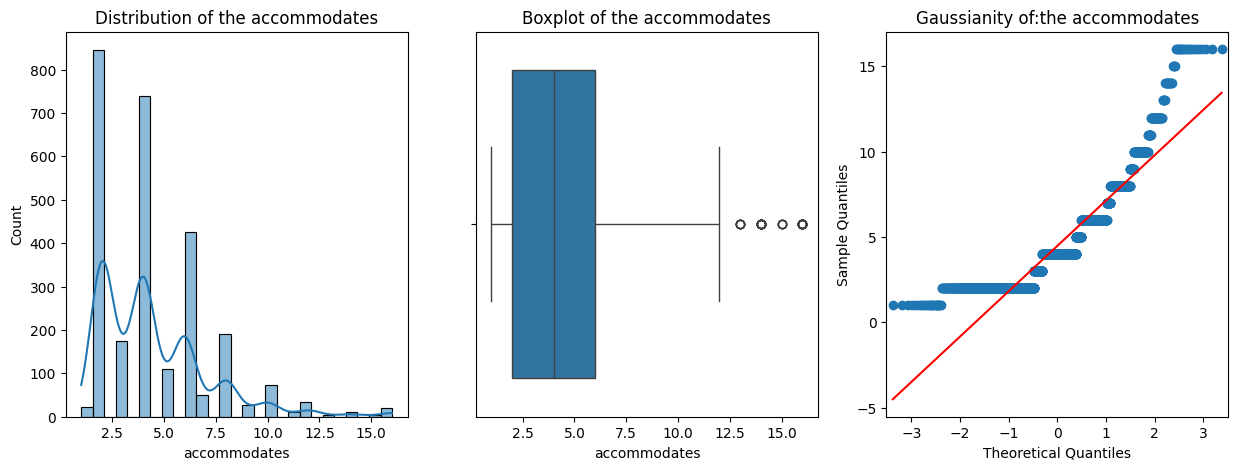

--------------------------------------------------


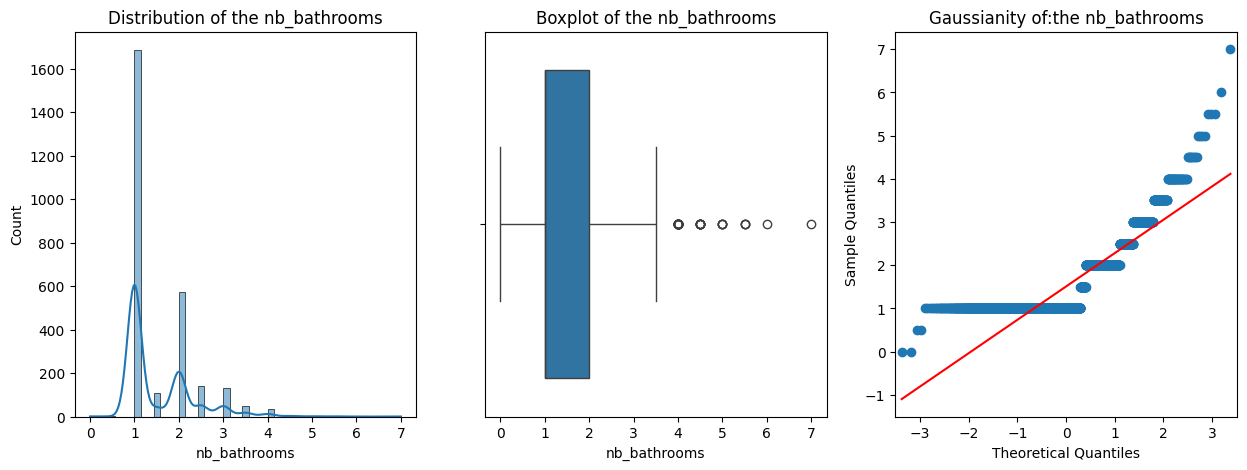

--------------------------------------------------


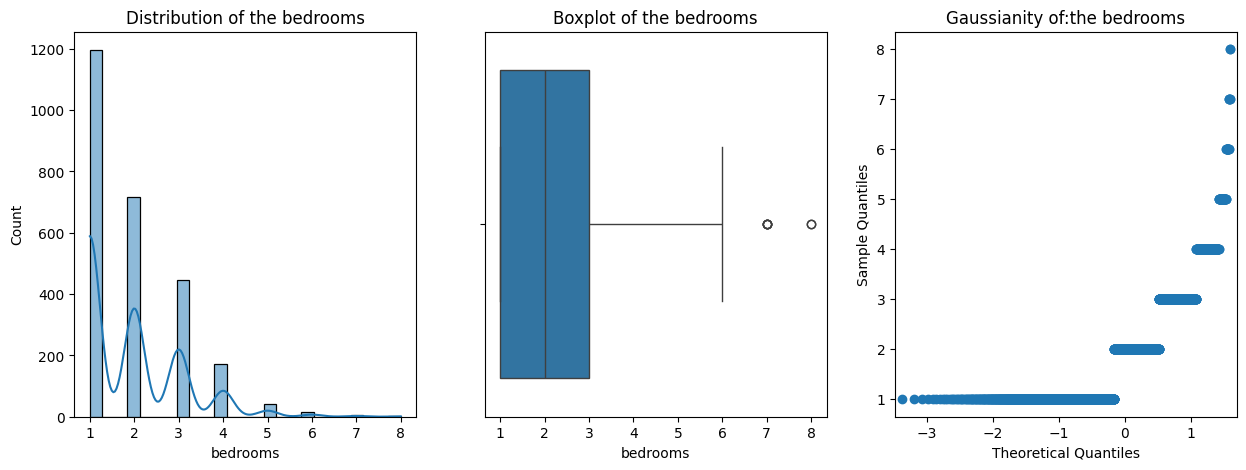

--------------------------------------------------


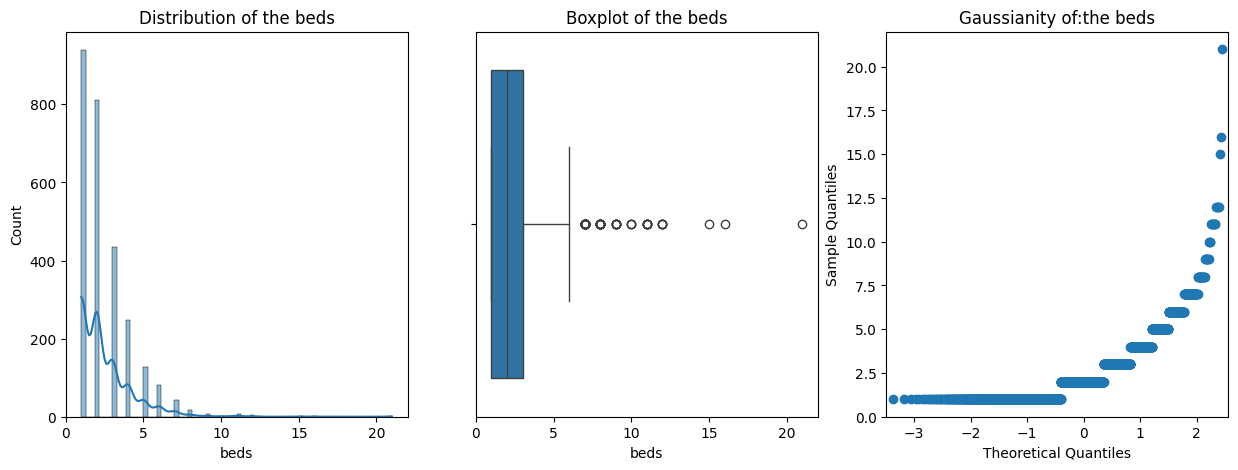

--------------------------------------------------


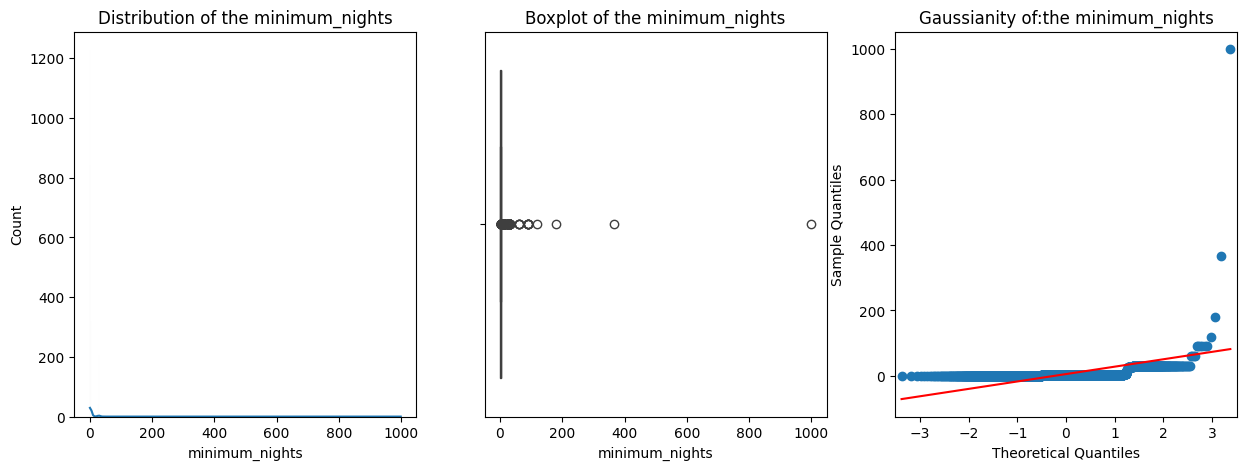

--------------------------------------------------


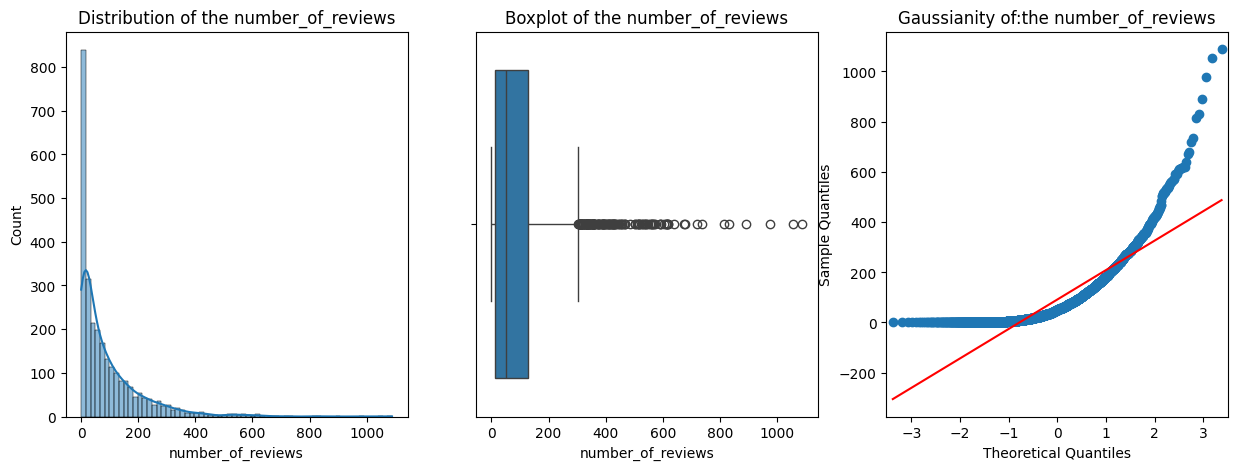

--------------------------------------------------


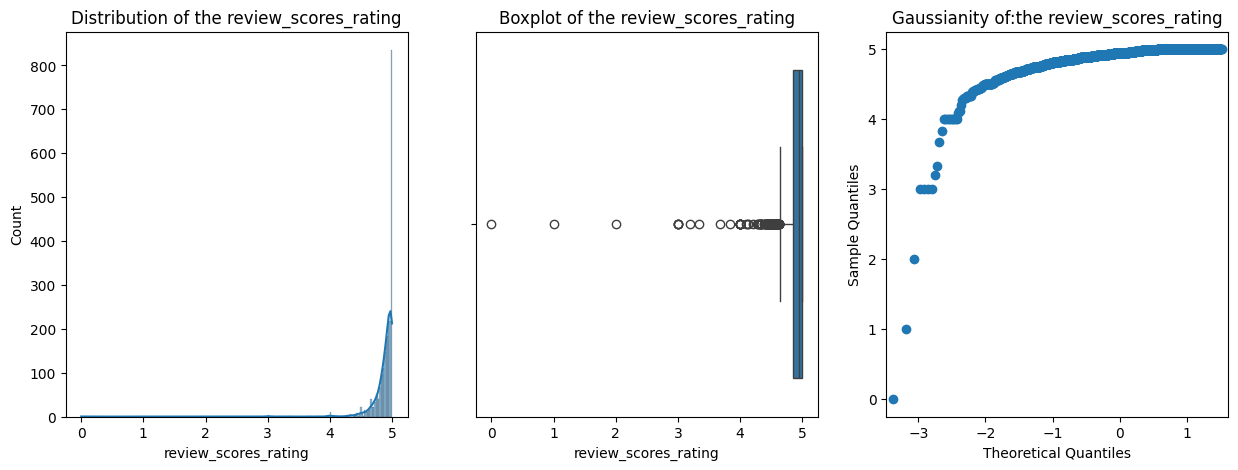

--------------------------------------------------


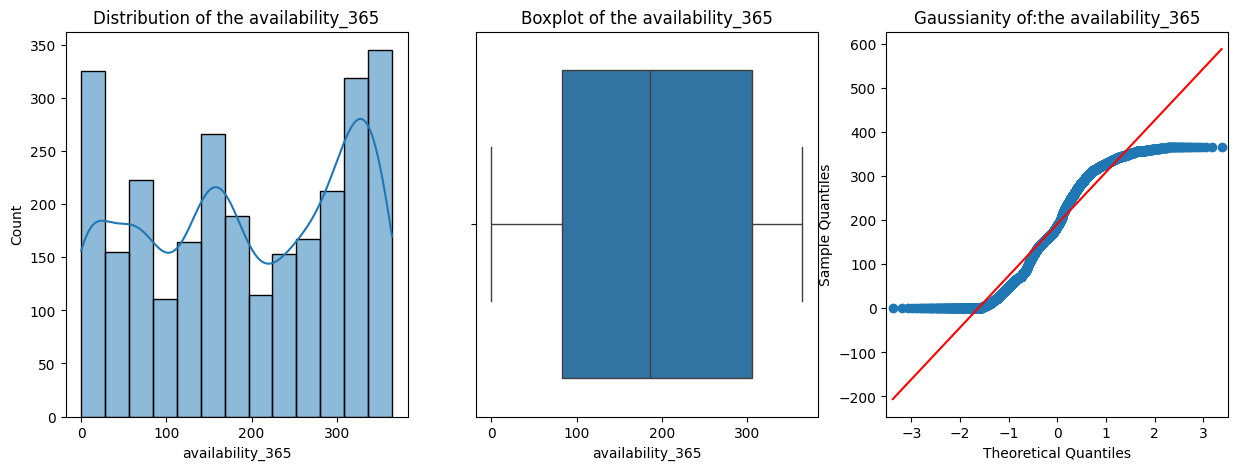

In [92]:
for variable in list(X_num.columns):
    print("-"*50)

    fig, ax = plt.subplots(1,3,figsize=(15,5))

    ax[0].set_title(f"Distribution of the {variable}")
    sns.histplot(data = X_num, x = f"{variable}", kde=True, ax = ax[0])

    ax[1].set_title(f"Boxplot of the {variable}")
    sns.boxplot(data = X_num, x = f"{variable}", ax=ax[1])

    ax[2].set_title(f"Gaussianity of:the {variable}")
    qqplot(X_num[f"{variable}"],line='s',ax=ax[2]);
    
    plt.show();

In [94]:
robust_features = ["minimum_nights", "number_of_reviews", "review_scores_rating"]
standard_features = []
minmax_features = ["accommodates", "bedrooms", "beds"]

In [95]:
scalers = ColumnTransformer([
    ("rob_scaler", RobustScaler(), robust_features),
    ("std_scaler", StandardScaler(), standard_features), 
    ("minmax_scaler", MinMaxScaler(), minmax_features),     
])

num_pipeline = Pipeline([
    ("num_imputer", SimpleImputer(strategy="median")),
    ("scaler", scalers)
]).set_output(transform="pandas")

num_pipeline

Pipeline(steps=[('num_imputer', SimpleImputer(strategy='median')),
                ('scaler',
                 ColumnTransformer(transformers=[('rob_scaler', RobustScaler(),
                                                  ['minimum_nights',
                                                   'number_of_reviews',
                                                   'review_scores_rating']),
                                                 ('std_scaler',
                                                  StandardScaler(), []),
                                                 ('minmax_scaler',
                                                  MinMaxScaler(),
                                                  ['accommodates', 'bedrooms',
                                                   'beds'])]))])

In [96]:
X_num.head()

,accommodates,nb_bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,availability_365
0,2,1.0,1.0,1.0,30,90,4.50,285
1,2,1.0,1.0,1.0,1,359,4.58,179
2,2,2.5,1.0,1.0,1,67,4.52,0
5,4,1.0,1.0,2.0,30,58,4.87,314
6,2,1.0,1.0,1.0,7,57,4.66,44


In [97]:
num_pipeline.fit_transform(X_num)

,rob_scaler__minimum_nights,rob_scaler__number_of_reviews,rob_scaler__review_scores_rating,minmax_scaler__accommodates,minmax_scaler__bedrooms,minmax_scaler__beds
0,28.0,0.341880,-3.384615,0.066667,0.000000,0.00
1,-1.0,2.641026,-2.769231,0.066667,0.000000,0.00
2,-1.0,0.145299,-3.230769,0.066667,0.000000,0.00
5,28.0,0.068376,-0.538462,0.200000,0.000000,0.05
6,5.0,0.059829,-2.153846,0.066667,0.000000,0.00
...,...,...,...,...,...,...
2850,0.0,0.282051,-1.384615,0.133333,0.142857,0.10
2852,0.0,0.461538,-1.153846,0.066667,0.142857,0.00
2853,0.0,-0.179487,0.461538,0.200000,0.000000,0.05
2854,1.0,-0.128205,0.000000,0.333333,0.285714,0.10


#### Encoding the categorical features

In [ ]:
onehot_features = [] 
ordinal_features = []

In [ ]:
encoders = ColumnTransformer([
    ("onehotencoder", OneHotEncoder(), onehot_features),
    ("ordinalencoder", OrdinalEncoder(), ordinal_features), 
])

cat_pipeline = Pipeline([
    ("cat_imputer", SimpleImputer(strategy="most_frequent")),
    ("encoders", encoders)
]).set_output(transform="pandas")

cat_pipeline

#### Final Preprocessor

### Modeling

#### Train-Test Split

#### Transform data

#### Linear Regression

#### Trying all the models!